# Модул 2: Pre-modeling Explainability
## EDA за Обясняемост, Документация на Данни и Интерпретируем Feature Engineering

**Предварителни изисквания:** Модул 1 завършен

**Цели:**
- Exploratory Data Analysis (EDA) с фокус върху обясняемост
- Създаване на Data Card за документация на датасет
- Интерпретируем Feature Engineering
- Анализ на връзките между features и target
- Идентифициране на потенциални източници на bias

**Време:** 50-60 минути

---

## 📚 СПРАВОЧЕН ЛИСТ

### Три Етапа на Обясняемост в ML:
1. **Pre-modeling** - Разбиране на данните ПРЕДИ моделиране
2. **In-modeling** - Използване на интерпретируеми модели
3. **Post-modeling** - Обяснение на "черни кутии" след обучение

### Pre-modeling Техники:
- **EDA** - Exploratory Data Analysis
- **Data Cards** - Документация на датасети
- **Feature Engineering** - Създаване на интерпретируеми features
- **Correlation Analysis** - Анализ на зависимости

### Pandas за EDA:
- `df.describe()` - статистическо резюме
- `df.info()` - информация за типове и липсващи стойности
- `df.corr()` - корелационна матрица
- `df.groupby('col').agg()` - групиране и агрегиране
- `df['col'].value_counts()` - честота на стойности
- `df['col'].quantile([0.25, 0.5, 0.75])` - квантили

### Визуализация:
- `sns.pairplot(df)` - матрица от scatter plots
- `sns.heatmap(corr, annot=True)` - топлинна карта
- `sns.boxplot(x='cat', y='num', data=df)` - boxplot по категории
- `sns.violinplot()` - violin plot за разпределения
- `plt.hist()` - хистограма

---

## Част 1: Зареждане и Първоначален Преглед (10 минути)

In [1]:
# Задача 1.1: Импортирайте библиотеките
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
sns.set_palette('husl')

print("Библиотеките са заредени успешно!")

Библиотеките са заредени успешно!


In [3]:
# Задача 1.2: Заредете Housing датасета
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv(
    '/content/drive/MyDrive/XAI/Housing.csv'
)
print(f"Датасет зареден успешно!")
print(f"Размер: {df.shape}")
print(f"\nПърви 5 реда:")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Датасет зареден успешно!
Размер: (545, 13)

Първи 5 реда:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Задача 1.3: Прегледайте структурата на данните
print("Информация за колоните:")
df.info()

Информация за колоните:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# Задача 1.4: Статистическо резюме на числовите колони
print("Статистическо резюме:")
df.describe().round(2)

Статистическо резюме:


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


## Част 2: Създаване на Data Card (15 минути)

**Data Card** е документ, който описва датасета по стандартизиран начин. Това е ключова практика за Pre-modeling Explainability.

In [6]:
# Задача 2.1: Създайте структура за Data Card

def create_data_card(df, dataset_name, description, source):
    """
    Създава Data Card за документация на датасет.

    Параметри:
    - df: DataFrame с данните
    - dataset_name: име на датасета
    - description: кратко описание
    - source: откъде са данните
    """

    print("="*70)
    print(f"DATA CARD: {dataset_name}")
    print("="*70)

    # Основна информация
    print(f"\nОПИСАНИЕ:")
    print(f"   {description}")
    print(f"\nИЗТОЧНИК: {source}")
    print(f"Дата на създаване на картата: {datetime.now().strftime('%Y-%m-%d')}")

    # Размер и структура
    print(f"\nРАЗМЕР:")
    print(f"   Редове: {df.shape[0]:,}")
    print(f"   Колони: {df.shape[1]}")

    # Типове колони
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    print(f"\nТИПОВЕ КОЛОНИ:")
    print(f"   Числови ({len(numeric_cols)}): {', '.join(numeric_cols)}")
    print(f"   Категорийни ({len(categorical_cols)}): {', '.join(categorical_cols)}")

    # Липсващи стойности
    missing = df.isnull().sum()
    print(f"\nЛИПСВАЩИ СТОЙНОСТИ:")
    if missing.sum() == 0:
        print("   Няма липсващи стойности")
    else:
        for col in missing[missing > 0].index:
            print(f"   {col}: {missing[col]} ({missing[col]/len(df)*100:.1f}%)")

    print("\n" + "="*70)

    return {
        'name': dataset_name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'numeric': numeric_cols,
        'categorical': categorical_cols
    }

In [7]:
# Задача 2.2: Създайте Data Card за Housing датасета
# Попълнете описанието и източника

data_card = create_data_card(
    df=df,
    dataset_name='Housing Price Dataset',
    description='Датасетът съдържа характеристики на жилища и съответните им цени, използвани за анализ и моделиране на цените на недвижими имоти.',
    source='Kaggle'
)


DATA CARD: Housing Price Dataset

ОПИСАНИЕ:
   Датасетът съдържа характеристики на жилища и съответните им цени, използвани за анализ и моделиране на цените на недвижими имоти.

ИЗТОЧНИК: Kaggle
Дата на създаване на картата: 2026-01-31

РАЗМЕР:
   Редове: 545
   Колони: 13

ТИПОВЕ КОЛОНИ:
   Числови (6): price, area, bedrooms, bathrooms, stories, parking
   Категорийни (7): mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus

ЛИПСВАЩИ СТОЙНОСТИ:
   Няма липсващи стойности



In [8]:
# Задача 2.3: Документирайте всяка колона

column_descriptions = {
    'price': 'Цена на жилището (target variable)',
    'area': 'Площ на жилището в квадратни фута',
    'bedrooms': 'Брой спални',
    'bathrooms': 'Брой бани',
    'stories': 'Брой етажи',
    'mainroad': 'Дали жилището е на главен път (yes/no)',
    'guestroom': 'Дали има стая за гости (yes/no)',
    'basement': 'Дали има мазе (yes/no)',
    'hotwaterheating': 'Дали има топла вода (yes/no)',
    'airconditioning': 'Дали има климатик (yes/no)',
    'parking': 'Брой паркоместа',
    'prefarea': 'Дали е в предпочитан район (yes/no)',
    'furnishingstatus': 'Статус на обзавеждане (furnished/semi-furnished/unfurnished)'
}

print("ОПИСАНИЕ НА КОЛОНИТЕ:")
print("-"*60)
for column, description in column_descriptions.items():
    print(f"{column:20s} | {description}")

ОПИСАНИЕ НА КОЛОНИТЕ:
------------------------------------------------------------
price                | Цена на жилището (target variable)
area                 | Площ на жилището в квадратни фута
bedrooms             | Брой спални
bathrooms            | Брой бани
stories              | Брой етажи
mainroad             | Дали жилището е на главен път (yes/no)
guestroom            | Дали има стая за гости (yes/no)
basement             | Дали има мазе (yes/no)
hotwaterheating      | Дали има топла вода (yes/no)
airconditioning      | Дали има климатик (yes/no)
parking              | Брой паркоместа
prefarea             | Дали е в предпочитан район (yes/no)
furnishingstatus     | Статус на обзавеждане (furnished/semi-furnished/unfurnished)


In [9]:
# Задача 2.4: Добавете информация за потенциални рискове и ограничения

print("\nПОТЕНЦИАЛНИ РИСКОВЕ И ОГРАНИЧЕНИЯ:")
print("-"*60)

risks = [
    "1. Данните може да не са представителни за всички региони",
    "2. Цените може да са остарели (не знаем датата на събиране)",
    "3. Липсва информация за местоположение (квартал, град)",
    "4. Бинарните features (yes/no) може да крият нюанси",
    "5. 'prefarea' е субективен - не знаем критериите"
]

for risk in risks:
    print(f"   {risk}")


ПОТЕНЦИАЛНИ РИСКОВЕ И ОГРАНИЧЕНИЯ:
------------------------------------------------------------
   1. Данните може да не са представителни за всички региони
   2. Цените може да са остарели (не знаем датата на събиране)
   3. Липсва информация за местоположение (квартал, град)
   4. Бинарните features (yes/no) може да крият нюанси
   5. 'prefarea' е субективен - не знаем критериите


## Част 3: EDA за Обясняемост (15 минути)

EDA в контекста на XAI не е просто разглеждане на данни - целта е да разберем **защо** моделът би могъл да вземе определени решения.

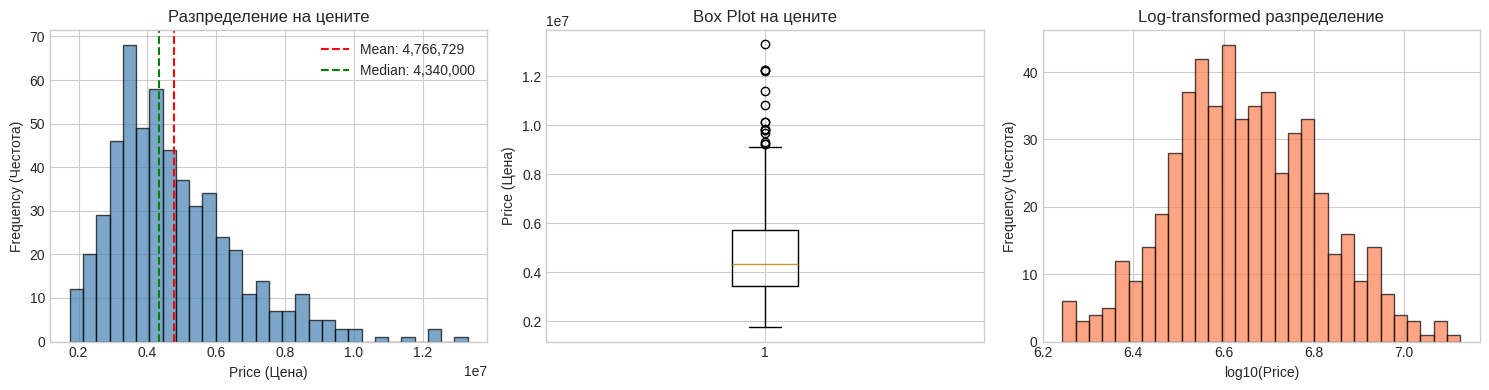

Skewness на цените: 1.21
Интерпретация: Силно положително изкривено


In [10]:
# Задача 3.1: Анализирайте разпределението на target variable (price)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Хистограма
axes[0].hist(df['price'], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_xlabel('Price (Цена)')
axes[0].set_ylabel('Frequency (Честота)')
axes[0].set_title('Разпределение на цените')
# Попълнете методите за изчисляване на средна стойност и медиана
axes[0].axvline(df['price'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--',
                label=f'Median: {df["price"].median():,.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('Price (Цена)')
axes[1].set_title('Box Plot на цените')

# Log-transformed histogram
axes[2].hist(np.log10(df['price']), bins=30, edgecolor='black', color='coral', alpha=0.7)
axes[2].set_xlabel('log10(Price)')
axes[2].set_ylabel('Frequency (Честота)')
axes[2].set_title('Log-transformed разпределение')

plt.tight_layout()
plt.show()

# Попълнете метода за изчисляване на skewness (изкривеност)
print(f"Skewness на цените: {df['price'].skew():.2f}")
print(f"Интерпретация: {'Силно положително изкривено' if df['price'].skew() > 1 else 'Умерено изкривено'}")

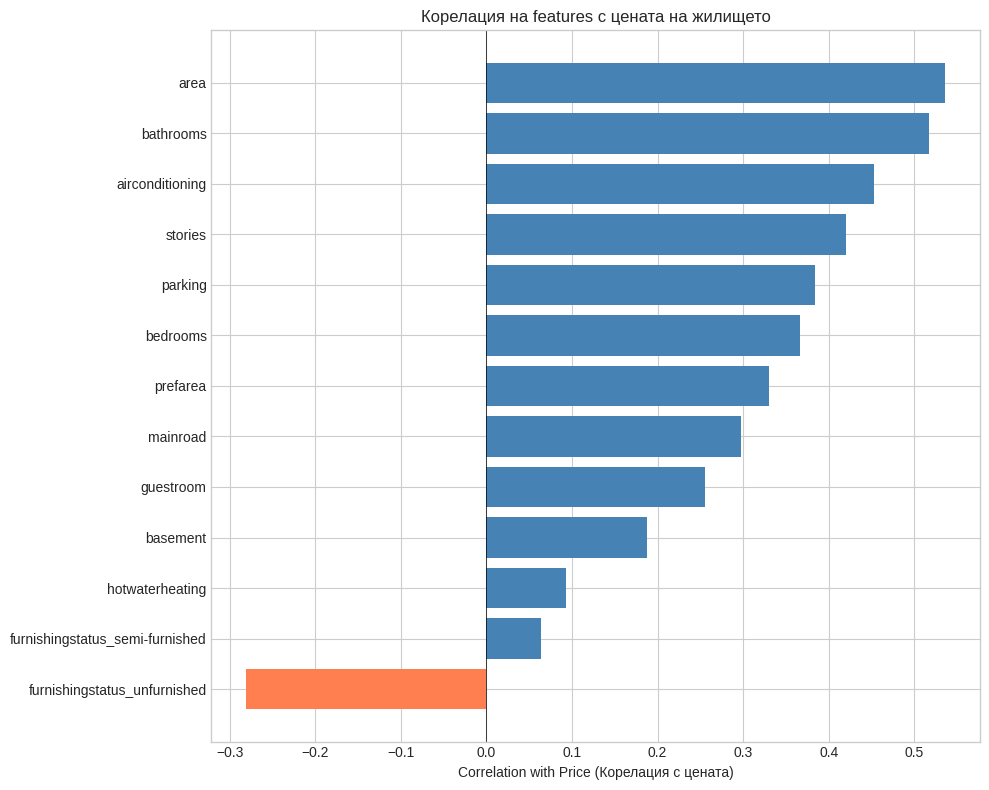

In [11]:
# Задача 3.2: Корелационен анализ - кои features са най-свързани с цената?

# Конвертираме бинарните колони за корелационен анализ
df_numeric = df.copy()
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

for col in binary_cols:
    df_numeric[col] = df_numeric[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus
df_numeric = pd.get_dummies(df_numeric, columns=['furnishingstatus'], drop_first=True)

# Изчислете корелационната матрица
correlation = df_numeric.corr()


# Визуализирайте корелацията с price
plt.figure(figsize=(10, 8))
price_correlation = correlation['price'].drop('price').sort_values(ascending=True)

colors = ['coral' if x < 0 else 'steelblue' for x in price_correlation]
plt.barh(price_correlation.index, price_correlation.values, color=colors)
plt.xlabel('Correlation with Price (Корелация с цената)')
plt.title('Корелация на features с цената на жилището')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

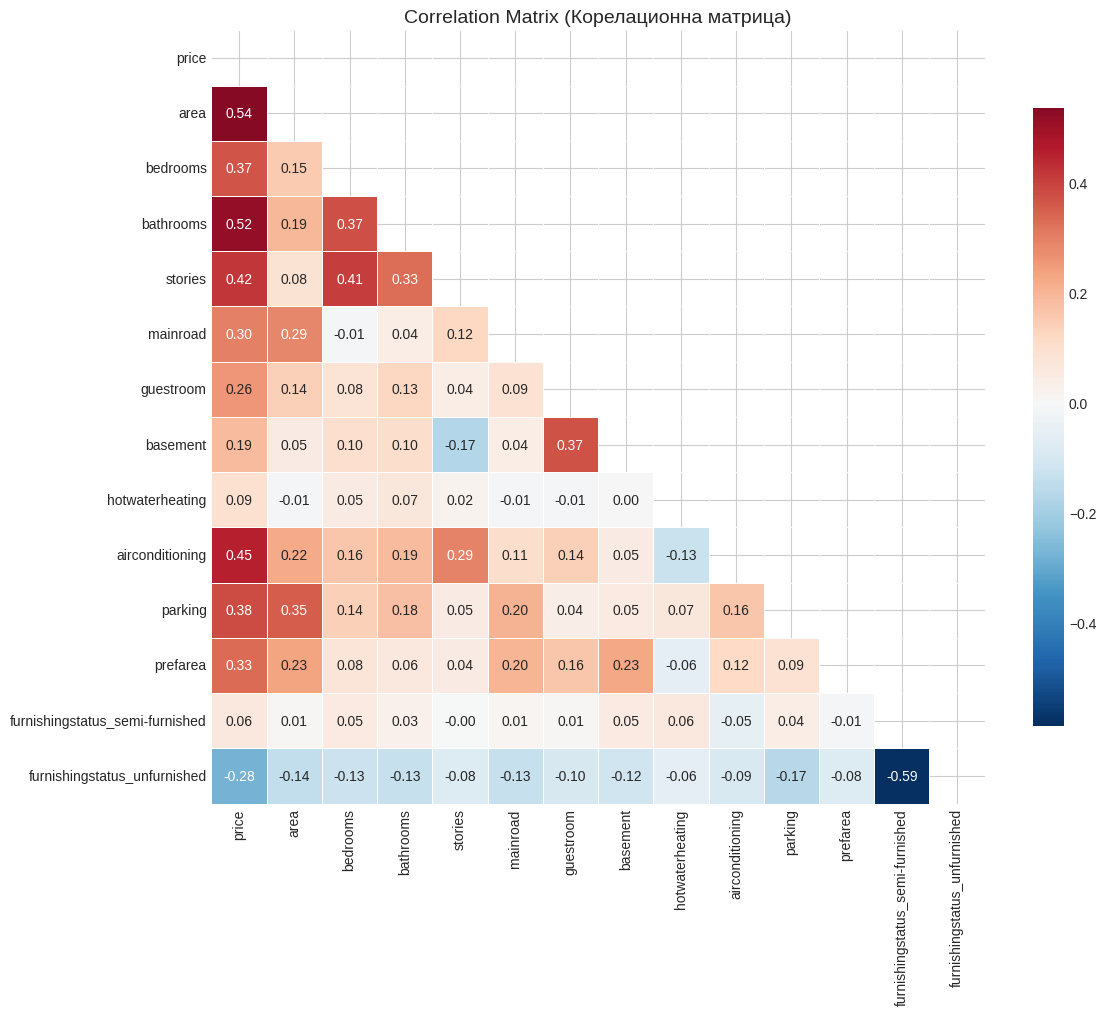

In [12]:
# Задача 3.3: Топлинна карта на всички корелации

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Корелационна матрица)', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Задача 3.4: Анализ на най-силно корелираните features

print("АНАЛИЗ НА НАЙ-ВАЖНИТЕ FEATURES:")
print("-"*50)

top_features = price_correlation.abs().sort_values(ascending=False).head(5)
print("\nТоп 5 features по корелация с цената:")
for feature, corr in top_features.items():
    sign = '+' if price_correlation[feature] > 0 else '-'
    print(f"  {feature}: {sign}{abs(corr):.3f}")

АНАЛИЗ НА НАЙ-ВАЖНИТЕ FEATURES:
--------------------------------------------------

Топ 5 features по корелация с цената:
  area: +0.536
  bathrooms: +0.518
  airconditioning: +0.453
  stories: +0.421
  parking: +0.384


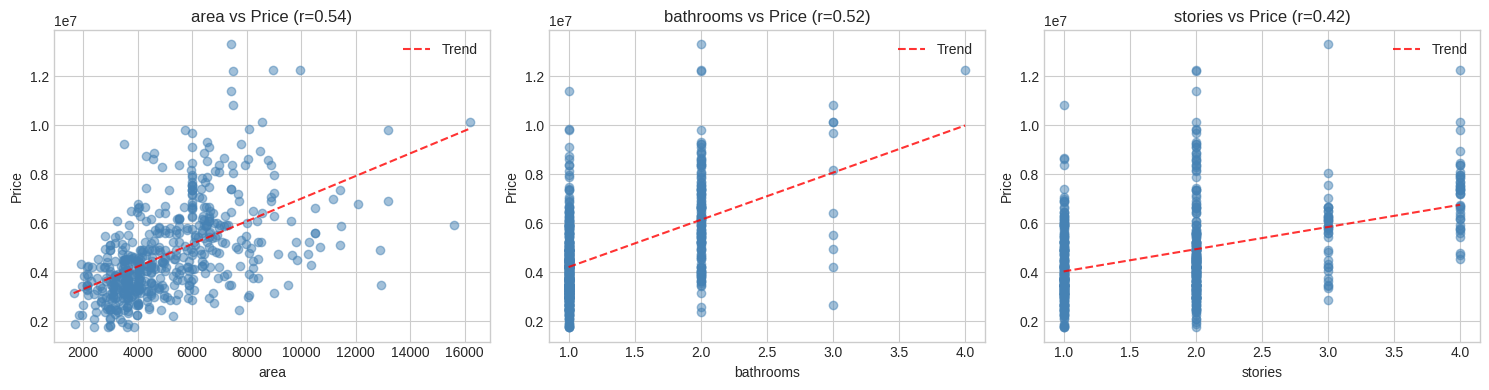

In [14]:
# Задача 3.5: Scatter plots за топ features

top_3 = ['area', 'bathrooms', 'stories']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(top_3):
    axes[i].scatter(df[feature], df['price'], alpha=0.5, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{feature} vs Price (r={price_correlation[feature]:.2f})')

    # Добавяме trend line (линейна регресия)
    # Попълнете функцията за полиномиално напасване (степен 1 = линейна)
    z = np.polyfit(df[feature], df['price'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[feature].sort_values(), p(df[feature].sort_values()),
                 "r--", alpha=0.8, label='Trend')
    axes[i].legend()

plt.tight_layout()
plt.show()

/tmp/ipython-input-3646636283.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='price', data=df, ax=axes[i], palette='Set2')
/tmp/ipython-input-3646636283.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='price', data=df, ax=axes[i], palette='Set2')
/tmp/ipython-input-3646636283.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='price', data=df, ax=axes[i], palette='Set2')
/tmp/ipython-input-3646636283.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

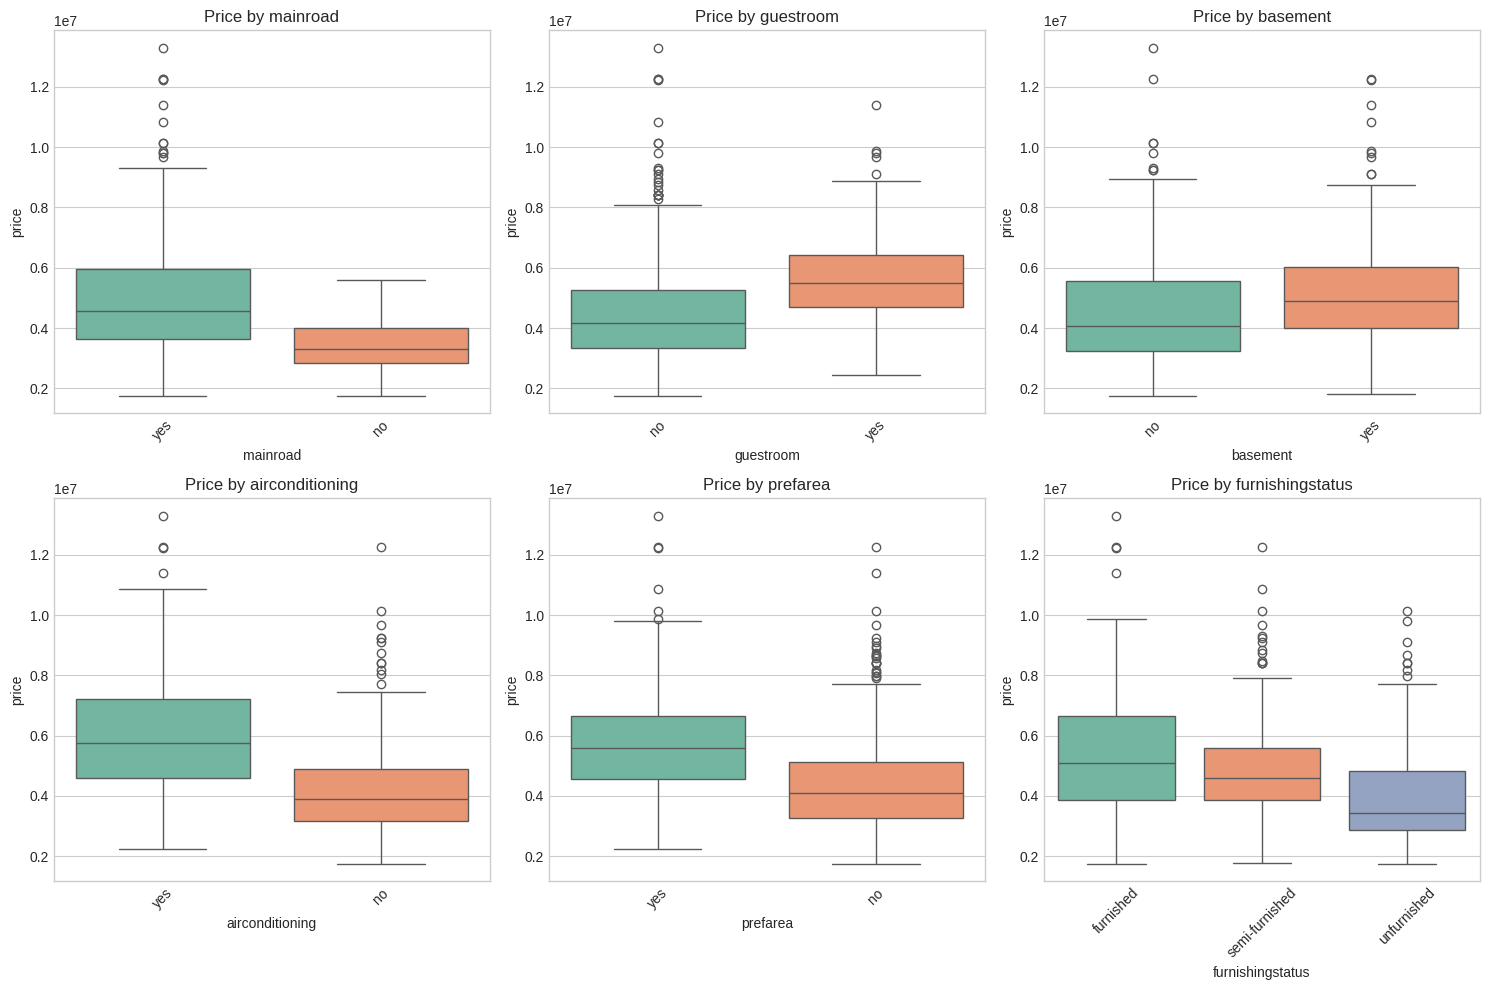

In [15]:
# Задача 3.6: Анализ на категорийни features

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

categorical_features = ['mainroad', 'guestroom', 'basement',
                        'airconditioning', 'prefarea', 'furnishingstatus']

for i, feature in enumerate(categorical_features):
    sns.boxplot(x=feature, y='price', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Price by {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 💡 Insight за обясняемост:

От EDA виждаме, че:
1. **area** е най-силно свързана с цената - интуитивно разбираемо
2. **airconditioning** и **prefarea** значително влияят на цената
3. Тези връзки са **интерпретируеми** - можем да обясним на клиент защо жилището е по-скъпо

## Част 4: Интерпретируем Feature Engineering (10 минути)

Създаваме нови features, които са **смислени и обясними** за хората.

In [16]:
# Задача 4.1: Създайте нов feature - цена на квадратен фут

df['price_per_sqft'] = df['price'] / df['area']

print("Статистика на цена/кв.фут:")
print(df['price_per_sqft'].describe().round(2))

Статистика на цена/кв.фут:
count     545.00
mean      993.33
std       346.54
min       270.40
25%       745.37
50%       952.38
75%      1184.62
max      2640.00
Name: price_per_sqft, dtype: float64


In [17]:
# Задача 4.2: Създайте feature за "луксозност" на жилището
# Комбинирайте няколко premium характеристики

df['luxury_score'] = (
    (df['airconditioning'] == 'yes').astype(int) +
    (df['guestroom'] == 'yes').astype(int) +
    (df['basement'] == 'yes').astype(int) +
    (df['prefarea'] == 'yes').astype(int) +
    (df['furnishingstatus'] == 'furnished').astype(int)
)

print("Разпределение на luxury score:")
print(df['luxury_score'].value_counts())

Разпределение на luxury score:
luxury_score
1    174
0    165
2    106
3     63
4     32
5      5
Name: count, dtype: int64


Корелация на luxury_score с price: 0.517


/tmp/ipython-input-608869510.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='luxury_score', y='price', data=df, palette='YlOrRd')


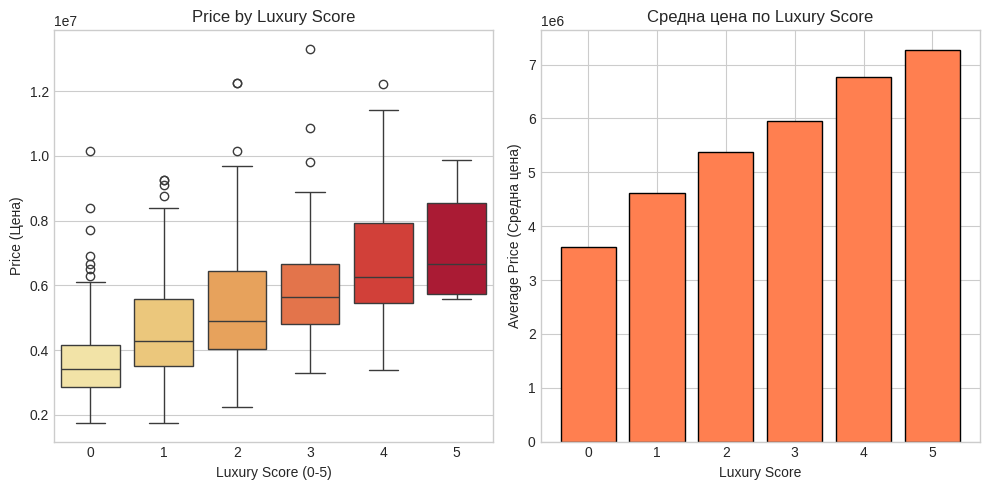

In [18]:
# Задача 4.3: Проверете корелацията на новия feature с цената

# Попълнете метода за изчисляване на корелация между две серии
luxury_correlation = df['luxury_score'].corr(df['price'])
print(f"Корелация на luxury_score с price: {luxury_correlation:.3f}")

# Визуализация
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='luxury_score', y='price', data=df, palette='YlOrRd')
plt.title('Price by Luxury Score')
plt.xlabel('Luxury Score (0-5)')
plt.ylabel('Price (Цена)')

plt.subplot(1, 2, 2)
# Попълнете метода за групиране и изчисляване на средна цена
avg_price = df.groupby('luxury_score')['price'].mean()
plt.bar(avg_price.index, avg_price.values, color='coral', edgecolor='black')
plt.xlabel('Luxury Score')
plt.ylabel('Average Price (Средна цена)')
plt.title('Средна цена по Luxury Score')

plt.tight_layout()
plt.show()

In [19]:
# Задача 4.4: Създайте категория за размер на жилището

# Определете границите на базата на квантили
# Попълнете стойностите за 25-ти и 75-ти перцентил
q25 = df['area'].quantile(0.25)
q75 = df['area'].quantile(0.75)

def categorize_size(area):
    if area < q25:
        return 'Small'
    elif area < q75:
        return 'Medium'
    else:
        return 'Large'

# Попълнете метода за прилагане на функция върху колона
df['size_category'] = df['area'].apply(categorize_size)

print("Разпределение по размер:")
print(df['size_category'].value_counts())

Разпределение по размер:
size_category
Medium    267
Large     142
Small     136
Name: count, dtype: int64


In [20]:
# Задача 4.5: Създайте "room density" - стаи на площ

df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['room_density'] = df['total_rooms'] / (df['area'] / 1000)  # стаи на 1000 sq ft

print("Статистика на room density:")
print(df['room_density'].describe().round(2))

Статистика на room density:
count    545.00
mean       0.95
std        0.42
min        0.23
25%        0.67
50%        0.86
75%        1.13
max        3.15
Name: room_density, dtype: float64


In [21]:
# Задача 4.6: Документирайте новите features

new_features = {
    'Feature': ['price_per_sqft', 'luxury_score', 'size_category', 'total_rooms', 'room_density'],
    'Description': [
        'Цена на квадратен фут',
        'Оценка за луксозност (0-5)',
        'Категория по размер (Small/Medium/Large)',
        'Общ брой стаи (спални + бани)',
        'Стаи на 1000 кв.фута'
    ],
    'Formula': [
        'price / area',
        'Sum of: AC, guestroom, basement, prefarea, furnished',
        'Based on area quantiles',
        'bedrooms + bathrooms',
        'total_rooms / (area/1000)'
    ],
    'Interpretation': [
        'По-висока стойност = по-скъпо на единица площ',
        'По-висока стойност = повече удобства',
        'Лесно разбираема категоризация',
        'Показва вместимост на жилището',
        'По-висока стойност = по-компактно жилище'
    ]
}

df_features = pd.DataFrame(new_features)
print("ДОКУМЕНТАЦИЯ НА НОВИ FEATURES:")
print("-"*80)
df_features

ДОКУМЕНТАЦИЯ НА НОВИ FEATURES:
--------------------------------------------------------------------------------


,Feature,Description,Formula,Interpretation
0,price_per_sqft,Цена на квадратен фут,price / area,По-висока стойност = по-скъпо на единица площ
1,luxury_score,Оценка за луксозност (0-5),"Sum of: AC, guestroom, basement, prefarea, fur...",По-висока стойност = повече удобства
2,size_category,Категория по размер (Small/Medium/Large),Based on area quantiles,Лесно разбираема категоризация
3,total_rooms,Общ брой стаи (спални + бани),bedrooms + bathrooms,Показва вместимост на жилището
4,room_density,Стаи на 1000 кв.фута,total_rooms / (area/1000),По-висока стойност = по-компактно жилище


## Част 5: Идентифициране на Потенциални Източници на Bias (10 минути)

In [22]:
# Задача 5.1: Проверете дали има дисбаланс в категорийните features

print("АНАЛИЗ НА ДИСБАЛАНС В ДАННИТЕ:")
print("="*50)

for col in binary_cols + ['furnishingstatus']:
    counts = df[col].value_counts()
    # Попълнете параметъра за получаване на пропорции вместо брой
    ratios = df[col].value_counts(normalize=True) * 100
    print(f"\n{col}:")
    for val in counts.index:
        print(f"  {val}: {counts[val]} ({ratios[val]:.1f}%)")

АНАЛИЗ НА ДИСБАЛАНС В ДАННИТЕ:

mainroad:
  yes: 468 (85.9%)
  no: 77 (14.1%)

guestroom:
  no: 448 (82.2%)
  yes: 97 (17.8%)

basement:
  no: 354 (65.0%)
  yes: 191 (35.0%)

hotwaterheating:
  no: 520 (95.4%)
  yes: 25 (4.6%)

airconditioning:
  no: 373 (68.4%)
  yes: 172 (31.6%)

prefarea:
  no: 417 (76.5%)
  yes: 128 (23.5%)

furnishingstatus:
  semi-furnished: 227 (41.7%)
  unfurnished: 178 (32.7%)
  furnished: 140 (25.7%)


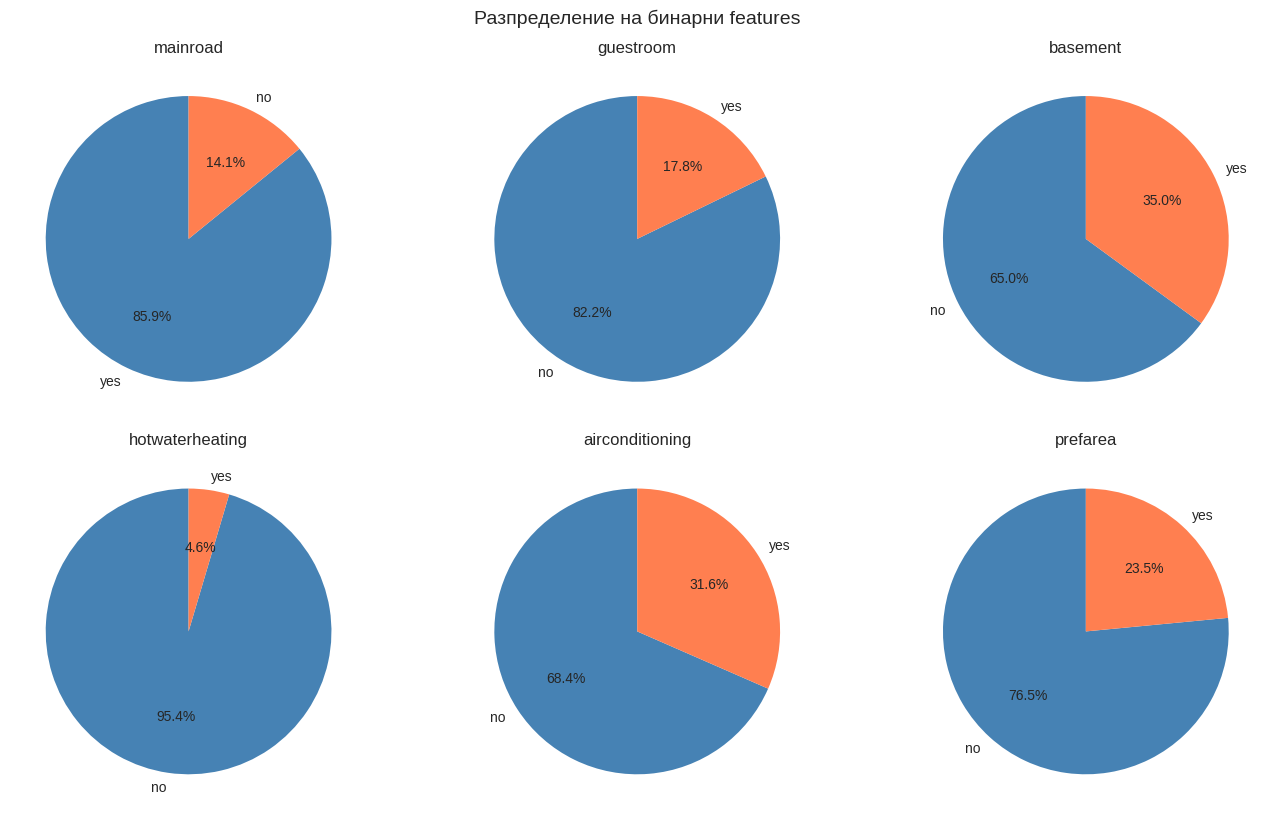

In [23]:
# Задача 5.2: Визуализирайте дисбаланса

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=['steelblue', 'coral'], startangle=90)
    axes[i].set_title(col)

plt.tight_layout()
plt.suptitle('Разпределение на бинарни features', y=1.02, fontsize=14)
plt.show()

In [24]:
# Задача 5.3: Идентифицирайте потенциални proxy variables

print("\nПОТЕНЦИАЛНИ PROXY VARIABLES:")
print("-"*60)
print("""
'prefarea' (предпочитан район) може да бъде proxy за:
- Социално-икономически статус на района
- Етнически/демографски състав
- Достъп до услуги и инфраструктура

Това е проблем, защото:
1. Моделът може да научи скрити дискриминационни patterns
2. Решенията може да изглеждат неутрални, но да отразяват
   исторически неравенства
""")


ПОТЕНЦИАЛНИ PROXY VARIABLES:
------------------------------------------------------------

'prefarea' (предпочитан район) може да бъде proxy за:
- Социално-икономически статус на района
- Етнически/демографски състав
- Достъп до услуги и инфраструктура

Това е проблем, защото:
1. Моделът може да научи скрити дискриминационни patterns
2. Решенията може да изглеждат неутрални, но да отразяват
   исторически неравенства



In [25]:
# Задача 5.4: Анализирайте взаимодействието между prefarea и други features

print("Средни стойности по prefarea:")
# Попълнете колоната за групиране (потенциална proxy variable)
comparison = df.groupby('prefarea')[['price', 'area', 'bedrooms', 'bathrooms']].mean().round(2)
print(comparison)

print(f"\nРазлика в средната цена: {comparison.loc['yes', 'price'] - comparison.loc['no', 'price']:,.0f}")
print(f"Разлика в средната площ: {comparison.loc['yes', 'area'] - comparison.loc['no', 'area']:,.0f}")

Средни стойности по prefarea:
               price     area  bedrooms  bathrooms
prefarea                                          
no        4425298.78  4868.52      2.93       1.27
yes       5879045.70  6069.32      3.07       1.34

Разлика в средната цена: 1,453,747
Разлика в средната площ: 1,201


In [26]:
# Задача 5.5: Създайте обобщение на потенциалните рискове

risk_analysis = {
    'Risk': [
        'Imbalance in hotwaterheating',
        'Proxy variable (prefarea)',
        'Missing geographic info',
        'Unclear furnishingstatus'
    ],
    'Description': [
        'Само 4.6% имат hot water heating - моделът може да overfit',
        'prefarea може да кодира социално-икономически фактори',
        'Не знаем града/квартала - ограничава генерализацията',
        'Не е ясно какво точно включва "furnished"'
    ],
    'Recommended_Action': [
        'Използвайте балансирани тежести или oversampling',
        'Документирайте и мониторирайте за disparate impact',
        'Не използвайте модела за други локации без валидация',
        'Добавете детайлна документация'
    ]
}

df_risks = pd.DataFrame(risk_analysis)
print("\nОБОБЩЕНИЕ НА РИСКОВЕТЕ:")
df_risks


ОБОБЩЕНИЕ НА РИСКОВЕТЕ:


,Risk,Description,Recommended_Action
0,Imbalance in hotwaterheating,Само 4.6% имат hot water heating - моделът мож...,Използвайте балансирани тежести или oversampling
1,Proxy variable (prefarea),prefarea може да кодира социално-икономически ...,Документирайте и мониторирайте за disparate im...
2,Missing geographic info,Не знаем града/квартала - ограничава генерализ...,Не използвайте модела за други локации без вал...
3,Unclear furnishingstatus,"Не е ясно какво точно включва ""furnished""",Добавете детайлна документация


## ✅ Модул 2 Завършен!

### Научихте:
- ✓ Как да създадете Data Card за документация на датасет
- ✓ EDA техники с фокус върху обясняемост
- ✓ Как да създавате интерпретируеми features
- ✓ Корелационен анализ за разбиране на връзките
- ✓ Идентифициране на потенциални източници на bias

### Основни изводи:
1. **Data Cards** са критични за прозрачност и възпроизводимост
2. **EDA** трябва да търси не само patterns, но и потенциални рискове
3. **Feature Engineering** трябва да създава смислени и обясними features
4. **Proxy variables** могат да въведат скрит bias в модела

### Следващ модул:
**Модул 3:** Decision Trees - Структура, интерпретация и обяснения

---

## 📝 Въпроси за самопроверка:

1. Какво е Data Card и защо е важен?
**Data Card** е документ, който описва произхода, съдържанието и ограниченията на датасета и е важен за прозрачност, откриване на предубеждения и отговорно използване на данните.
2. Какви са трите етапа на обясняемост в ML?
**Трите етапа** на обясняемост в ML са pre-model, in-model,post-hoc
3. Какво е proxy variable и защо е проблем?
**Proxy variable** е променлива, която индиректно представя чувствителен атрибут и е проблем, защото може да доведе до скрита дискриминация.
4. Кои features от Housing датасета са най-силно корелирани с цената?
В датасета най-силно корелирани с цената са features като area,bathrooms и stories, които директно описват размера и комфорта на жилището.
5. Защо luxury_score е интерпретируем feature?
Защото комбинира ясно разбираеми характеристики на жилището в един интуитивен показател за луксозност.